In [1]:
#Import Libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from datetime import datetime as dt
import os

In [2]:
import matplotlib
matplotlib.__version__

'3.10.0'

In [3]:
path=r"C:\Users\neuma\OneDrive\Desktop\Specialisation\NY_CityBike_Analysis\df_merged_365.parquet"

In [4]:
path_file=os.path.join(path)

In [5]:
df=pd.read_parquet(path_file)

In [6]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'avgTemp'],
      dtype='object')

In [7]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,avgTemp
0,BFD29218AB271154,electric_bike,2022-01-21 13:13:43.392,2022-01-21 13:22:31.463,West End Ave & W 107 St,7650.05,Mt Morris Park W & W 120 St,7685.14,40.802117,-73.968181,40.804038,-73.945925,member,2022-01-21,-10.0
1,7C953F2FD7BE1302,classic_bike,2022-01-10 11:30:54.162,2022-01-10 11:41:43.422,4 Ave & 3 St,4028.04,Boerum Pl\t& Pacific St,4488.09,40.673746,-73.985649,40.688489,-73.991160,member,2022-01-10,-10.6
2,95893ABD40CED4B8,electric_bike,2022-01-26 10:52:43.096,2022-01-26 11:06:35.227,1 Ave & E 62 St,6753.08,5 Ave & E 29 St,6248.06,40.761227,-73.960940,40.745168,-73.986831,member,2022-01-26,-16.6
3,F853B50772137378,classic_bike,2022-01-03 08:35:48.247,2022-01-03 09:10:50.475,2 Ave & E 96 St,7338.02,5 Ave & E 29 St,6248.06,40.783964,-73.947167,40.745168,-73.986831,member,2022-01-03,-9.2
4,7590ADF834797B4B,classic_bike,2022-01-22 14:14:23.043,2022-01-22 14:34:57.474,6 Ave & W 34 St,6364.10,5 Ave & E 29 St,6248.06,40.749640,-73.988050,40.745168,-73.986831,member,2022-01-22,-5.0


In [8]:
df.shape

(29838806, 15)

In [9]:
df.dtypes

ride_id               string[python]
rideable_type                 object
started_at                    object
ended_at                      object
start_station_name    string[python]
start_station_id      string[python]
end_station_name      string[python]
end_station_id        string[python]
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
date                          object
avgTemp                      float64
dtype: object

## Line plot average temperatures NY 2022

In [10]:
df_temp=df[['date', 'avgTemp']].dropna()
df_temp=df_temp.sort_values('date')
df_temp=df_temp.set_index('date') #sorting and indexing the df based on the date first

In [11]:
df_temp.head()  #check

,avgTemp
date,
2022-01-01,2.0
2022-01-01,2.0
2022-01-01,2.0
2022-01-01,2.0
2022-01-01,2.0


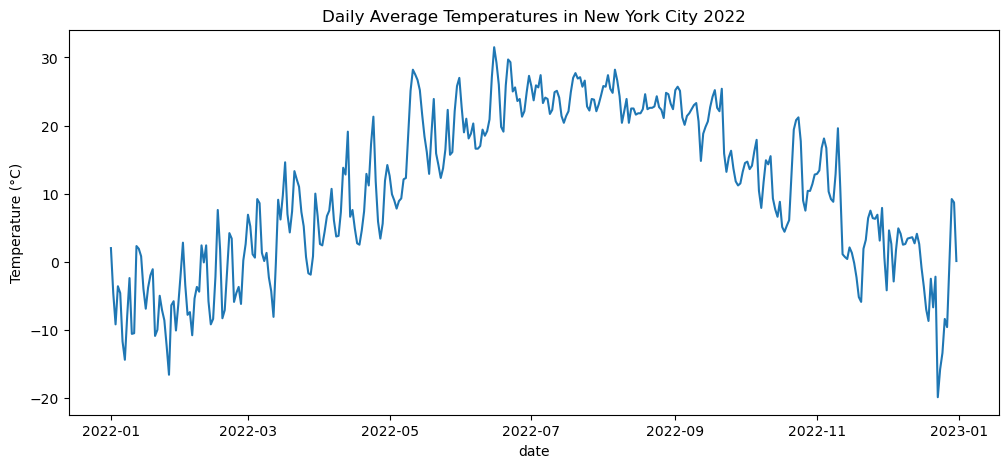

In [12]:
#plot

df_temp['avgTemp'].plot(
    figsize=(12,5),
    title="Daily Average Temperatures in New York City 2022", #adding title
    ylabel="Temperature (°C)"
)
plt.show()

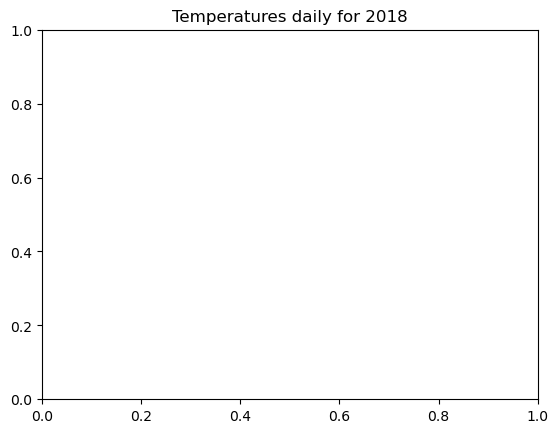

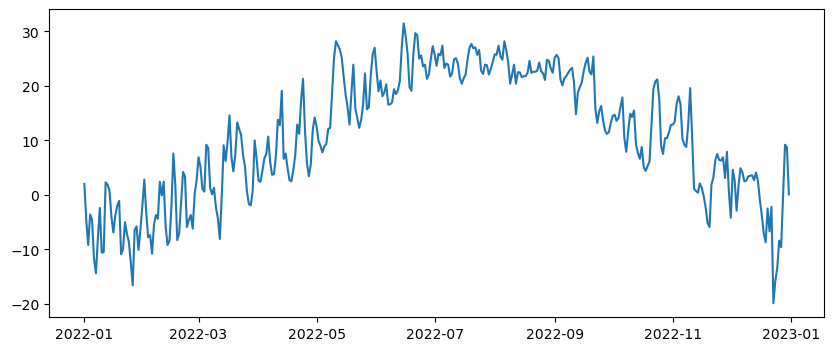

In [14]:
plt.title("Temperatures daily for 2018")
plt.figure(figsize=(10,4))
plt.plot(df_temp['avgTemp'])
plt.show()

### Trips per day

In [13]:
df_group = (
    df.loc[:, ["date", "ride_id"]]   
      .groupby("date", as_index=False)
      .agg(trips=("ride_id", "count"))
)

In [14]:
df_group

,date,trips
0,2021-01-30,1
1,2021-02-15,1
2,2021-03-11,1
3,2021-03-14,1
4,2021-03-31,1
...,...,...
397,2022-12-27,33044
398,2022-12-28,44027
399,2022-12-29,51674
400,2022-12-30,62298


In [15]:
df_group_1= pd.DataFrame(df.groupby(['date'])['ride_id'].count()).reset_index()

In [16]:
df_group_1.tail()

,date,ride_id
397,2022-12-27,33044
398,2022-12-28,44027
399,2022-12-29,51674
400,2022-12-30,62298
401,2022-12-31,31466


In [17]:
df['day']=pd.to_datetime(df['started_at']).dt.date

In [18]:
df_daily=(
    df.groupby("date", as_index=False)
      .agg(trips=("ride_id", "count"))
)

In [19]:
df_daily

,date,trips
0,2021-01-30,1
1,2021-02-15,1
2,2021-03-11,1
3,2021-03-14,1
4,2021-03-31,1
...,...,...
397,2022-12-27,33044
398,2022-12-28,44027
399,2022-12-29,51674
400,2022-12-30,62298


In [20]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,avgTemp,day
0,BFD29218AB271154,electric_bike,2022-01-21 13:13:43.392,2022-01-21 13:22:31.463,West End Ave & W 107 St,7650.05,Mt Morris Park W & W 120 St,7685.14,40.802117,-73.968181,40.804038,-73.945925,member,2022-01-21,-10.0,2022-01-21
1,7C953F2FD7BE1302,classic_bike,2022-01-10 11:30:54.162,2022-01-10 11:41:43.422,4 Ave & 3 St,4028.04,Boerum Pl\t& Pacific St,4488.09,40.673746,-73.985649,40.688489,-73.991160,member,2022-01-10,-10.6,2022-01-10
2,95893ABD40CED4B8,electric_bike,2022-01-26 10:52:43.096,2022-01-26 11:06:35.227,1 Ave & E 62 St,6753.08,5 Ave & E 29 St,6248.06,40.761227,-73.960940,40.745168,-73.986831,member,2022-01-26,-16.6,2022-01-26
3,F853B50772137378,classic_bike,2022-01-03 08:35:48.247,2022-01-03 09:10:50.475,2 Ave & E 96 St,7338.02,5 Ave & E 29 St,6248.06,40.783964,-73.947167,40.745168,-73.986831,member,2022-01-03,-9.2,2022-01-03
4,7590ADF834797B4B,classic_bike,2022-01-22 14:14:23.043,2022-01-22 14:34:57.474,6 Ave & W 34 St,6364.10,5 Ave & E 29 St,6248.06,40.749640,-73.988050,40.745168,-73.986831,member,2022-01-22,-5.0,2022-01-22


In [21]:
df=df.merge(df_daily, on="date", how="left")

In [24]:
df_daily['date']=pd.to_datetime(df_daily['date'])

In [28]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'avgTemp', 'day', 'trips'],
      dtype='object')

In [29]:
df = df.drop(columns=["day"], errors="ignore")

In [30]:
df_daily=df.groupby("date")["ride_id"].count().reset_index()
df_daily=df_daily.rename(columns={"ride_id": "trips"})

In [32]:
df=df.merge(df_daily, on="date", how="left")

In [36]:
df.columns.tolist()

['ride_id',
 'rideable_type',
 'started_at',
 'ended_at',
 'start_station_name',
 'start_station_id',
 'end_station_name',
 'end_station_id',
 'start_lat',
 'start_lng',
 'end_lat',
 'end_lng',
 'member_casual',
 'date',
 'avgTemp',
 'trips_x',
 'trips_y']

In [38]:
df = df.drop(columns=['trips_y'])
df = df.rename(columns={'trips_x': 'trips'})

In [40]:
df_daily = (
    df[['date', 'avgTemp', 'trips']]
    .drop_duplicates(subset='date')
    .sort_values('date')
    .reset_index(drop=True)
)

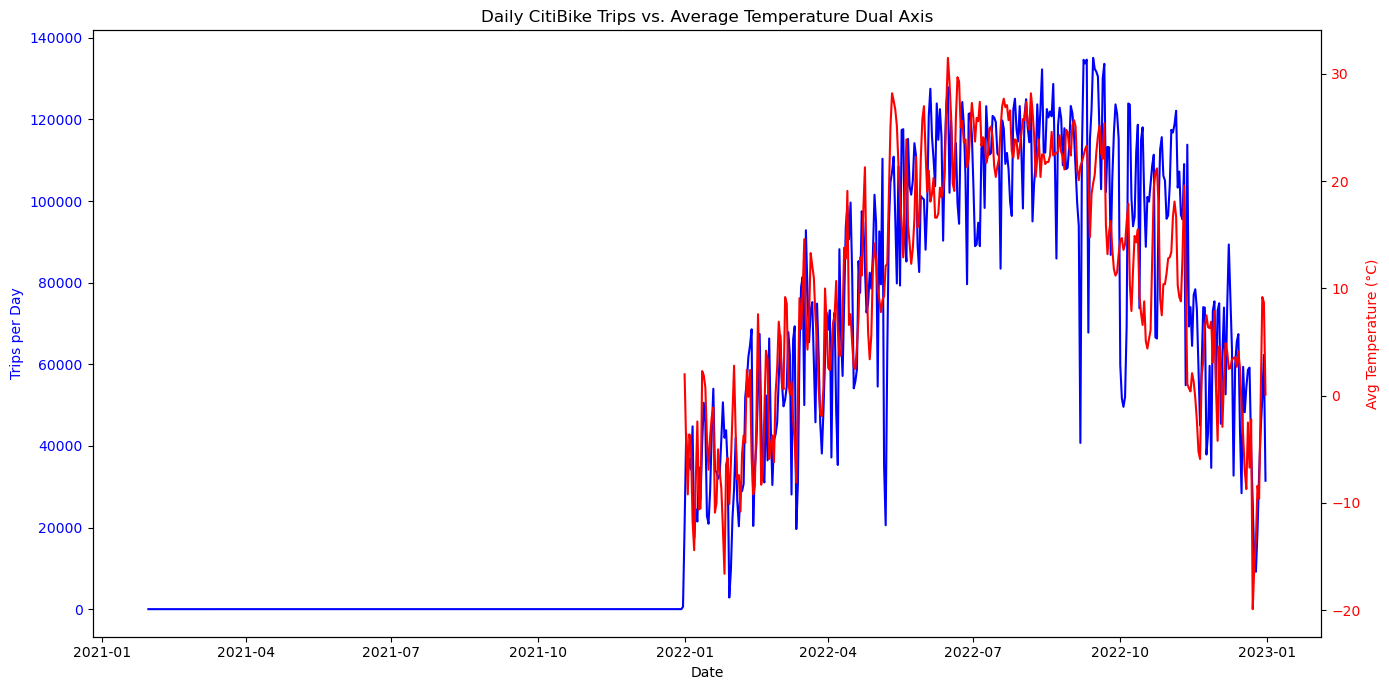

In [41]:
fig, ax1=plt.subplots(figsize=(14,7))

ax1.plot(df_daily["date"], df_daily["trips"], label="Trips per Day", color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Trips per Day", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(df_daily["date"], df_daily["avgTemp"], label="Avg Temperature", color="red")
ax2.set_ylabel("Avg Temperature (°C)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Daily CitiBike Trips vs. Average Temperature Dual Axis")
plt.tight_layout()
plt.show()

### Explanation of the Plot

This visualization uses matplotlib’s object-oriented paradigm to compare the daily Citibike trip counts with the average temperatures.
The object-oriented paradigm gives more control over:
multiple axes,layout and figure organization, per-axis styling.

The two stacked subplots were created to:

- ax1 for plotting daily trip counts
- ax2 for plotting average temperatures

### filtered out the 2021 entries


In [44]:
df["date"]=pd.to_datetime(df["date"])

In [45]:
df=df[df["date"].dt.year == 2022].copy()

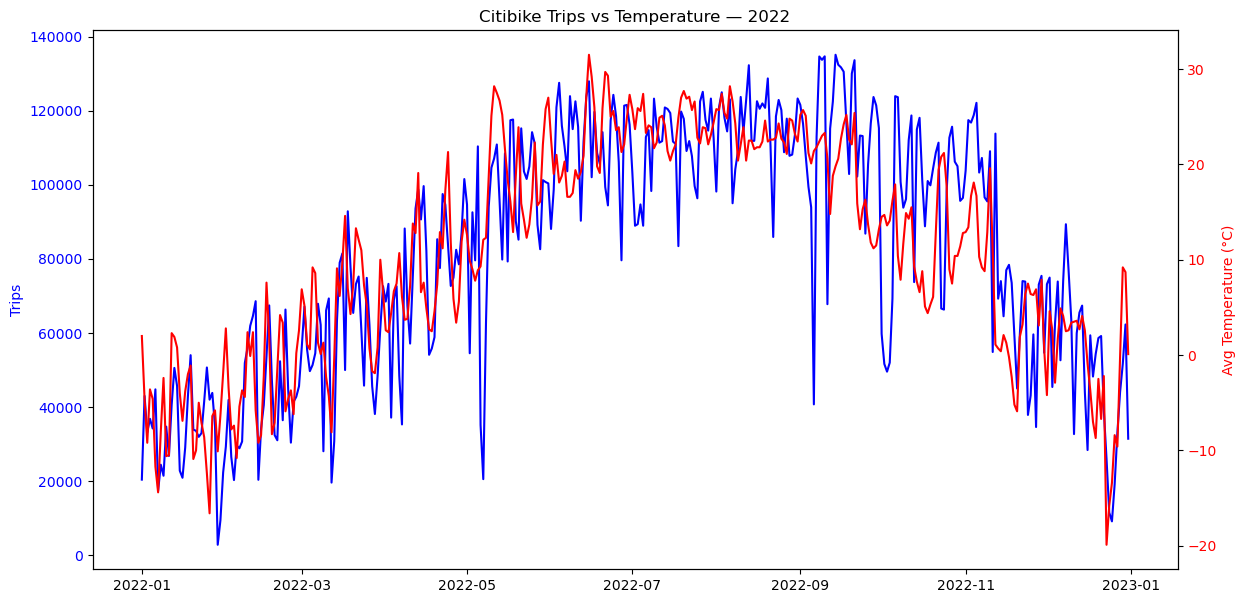

In [47]:
df_2022=df[df["date"].dt.year == 2022]

fig, ax1=plt.subplots(figsize=(14,7))

ax1.plot(df_2022["date"], df_2022["trips"], color="blue", label="Trips 2022")
ax1.set_ylabel("Trips", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(df_2022["date"], df_2022["avgTemp"], color="red", label="AvgTemp 2022")
ax2.set_ylabel("Avg Temperature (°C)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Citibike Trips vs Temperature — 2022")
plt.show()